LOAN APPLICATION FAIRNESS ANALYSIS

Objective:

Train a classifier without the group column and investigate

whether it produces different outcomes for groups A and B.

Dataset Shape: (6000, 8)


,applicant_id,group,income,years_employed,credit_score,debt_ratio,loan_amount,repaid
0,AP00001,A,92281.0,4.6,762.0,0.060,44700.0,0
1,AP00002,B,31527.0,1.2,545.0,0.373,19600.0,0
2,AP00003,B,21887.0,6.2,684.0,0.041,20200.0,0
3,AP00004,A,58059.0,8.2,675.0,0.235,48000.0,0
4,AP00005,A,58698.0,11.1,678.0,0.409,99500.0,0



Missing Values:
applicant_id      0
group             0
income            0
years_employed    0
credit_score      0
debt_ratio        0
loan_amount       0
repaid            0
dtype: int64

Group Distribution:
group
A    4332
B    1668
Name: count, dtype: int64

Overall Model Accuracy: 0.7573

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.97      0.86      1113
           1       0.63      0.15      0.24       387

    accuracy                           0.76      1500
   macro avg       0.70      0.56      0.55      1500
weighted avg       0.73      0.76      0.70      1500


BASELINE FAIRNESS RESULTS


,Group,Threshold,Sample Size,Precision,Recall,Approval Rate
0,A,0.5,1072,0.6292,0.1824,0.0830
1,B,0.5,428,0.5000,0.0125,0.0047



Baseline Group A - Group B Differences:
Precision        0.1292
Recall           0.1699
Approval Rate    0.0783
dtype: float64

FEATURE COMPARISON BY GROUP:


group,A,B,Difference (A-B)
income,61759.381,44055.484,17703.897
years_employed,7.021,4.750,2.271
credit_score,686.737,639.763,46.974
debt_ratio,0.228,0.221,0.007
loan_amount,61617.613,44720.024,16897.589


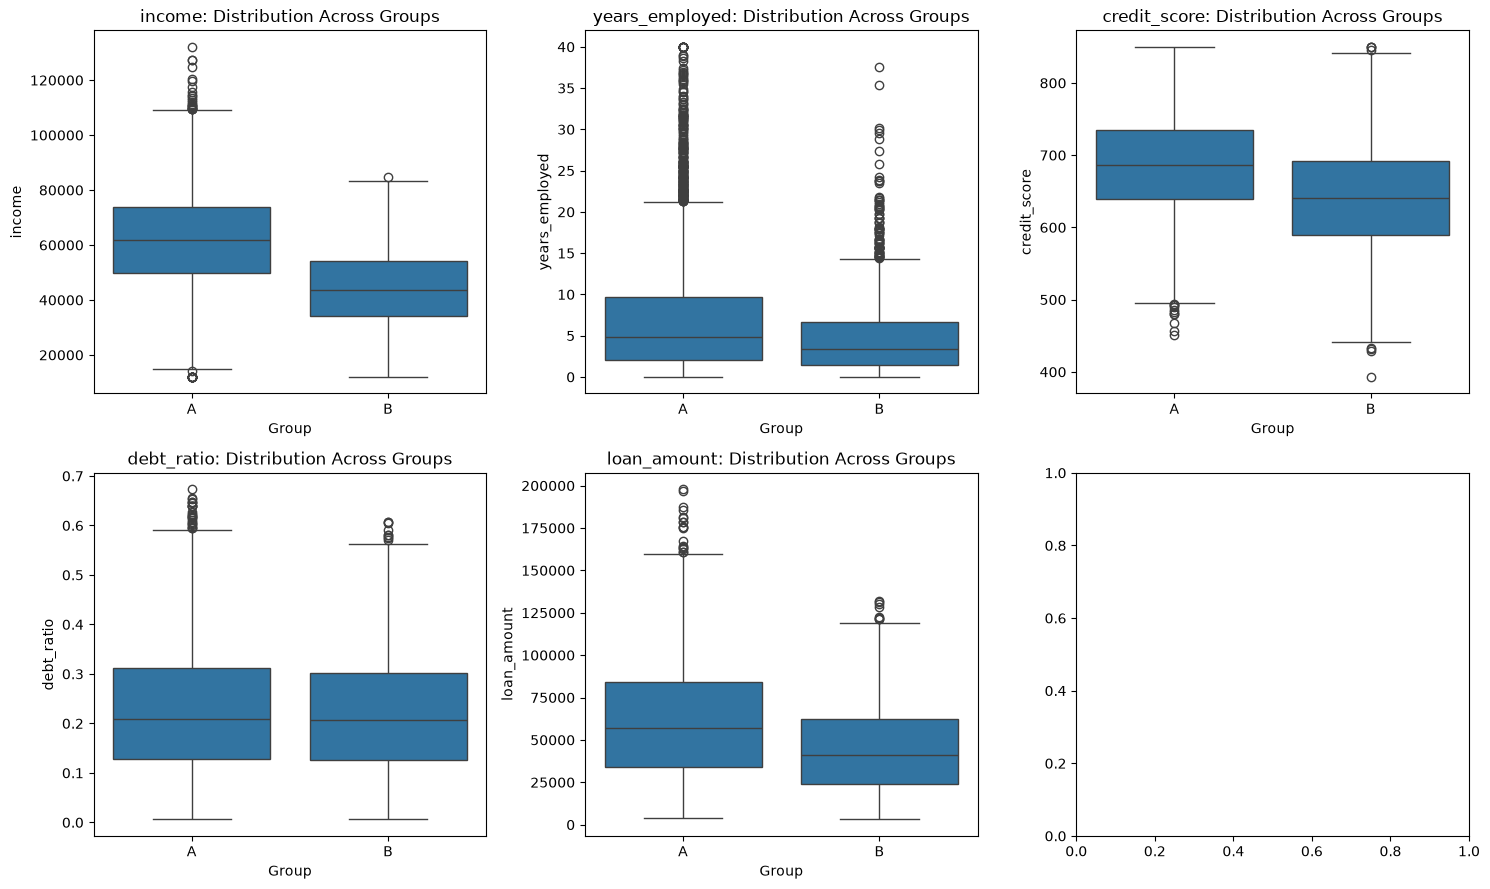


GROUP PROXY MODEL RESULTS
Accuracy for predicting group from neutral features: 0.784

Most Informative Proxy Features:


,Absolute Coefficient
income,1.243304
credit_score,0.700252
years_employed,0.421893
loan_amount,0.116943
debt_ratio,0.033247



TUNED THRESHOLDS:
{'A': np.float64(0.499), 'B': np.float64(0.315)}

TUNED FAIRNESS RESULTS


,Group,Threshold,Sample Size,Precision,Recall,Approval Rate
0,A,0.499,1072,0.6292,0.1824,0.0830
1,B,0.315,428,0.5000,0.2250,0.0841



BEFORE AND AFTER COMPARISON:


,Group,Precision_Before,Recall_Before,Approval Rate_Before,Precision_After,Recall_After,Approval Rate_After
0,A,0.6292,0.1824,0.0830,0.6292,0.1824,0.0830
1,B,0.5000,0.0125,0.0047,0.5000,0.2250,0.0841



FAIRNESS GAP COMPARISON:


,Fairness Measure,Before Tuning,After Tuning
0,Precision Gap,0.1292,0.1292
1,Recall Gap,0.1699,0.0426
2,Approval Rate Gap,0.0783,0.0011


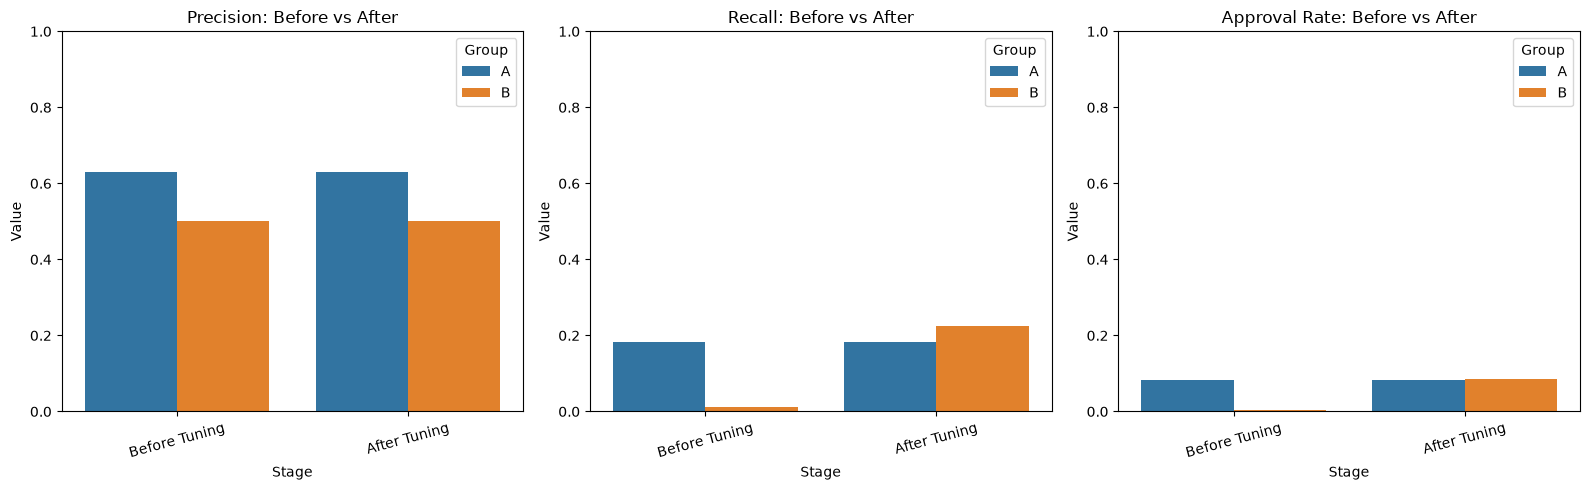


FINAL FAIRNESS INTERPRETATION
Approval rate gap before tuning: 0.0783
Approval rate gap after tuning: 0.0011
Recall gap before tuning: 0.1699
Recall gap after tuning: 0.0426

Fairness measure targeted: Approval rate parity.
The threshold adjustment may change precision and recall differently across groups. Compare the reported gaps rather than assuming that improving one measure improves all.


In [6]:

# ============================================================
# LOAN APPLICATION FAIRNESS ANALYSIS
# Objective:
# Train a classifier without the group column and investigate
# whether it produces different outcomes for groups A and B.
# ============================================================

# ------------------------------------------------------------
# 1. Import necessary libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# 2. Load and inspect the dataset
# ------------------------------------------------------------

df = pd.read_csv("loan_applications.csv")

print("Dataset Shape:", df.shape)
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nGroup Distribution:")
print(df["group"].value_counts())

# ------------------------------------------------------------
# 3. Prepare features and target
# ------------------------------------------------------------

# Remove group and applicant_id from model features.
# applicant_id is an identifier, not a meaningful predictor.
# The model must never receive the protected group column.

X = df.drop(columns=["group", "applicant_id", "repaid"])
y = df["repaid"]

# Keep group separately for fairness auditing only.
groups = df["group"]

# ------------------------------------------------------------
# 4. Split the data into training and testing sets
# ------------------------------------------------------------

X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X,
    y,
    groups,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 5. Train Logistic Regression classifier
# ------------------------------------------------------------

# StandardScaler standardizes numerical features.
# Logistic Regression predicts the probability of repayment.

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model.fit(X_train, y_train)

# Predict repayment probabilities.
y_probability = model.predict_proba(X_test)[:, 1]

# Standard classification threshold.
DEFAULT_THRESHOLD = 0.50

y_pred = (y_probability >= DEFAULT_THRESHOLD).astype(int)

print("\nOverall Model Accuracy:",
      round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ------------------------------------------------------------
# 6. Create fairness evaluation function
# ------------------------------------------------------------

def fairness_report(y_true, probabilities, group_data, thresholds):
    """
    Calculate precision, recall and approval rate separately
    for each group.

    Approval rate = Percentage of applicants predicted positive.
    """

    results = []

    for group in sorted(group_data.unique()):

        # Select applicants belonging to the current group.
        mask = (group_data == group).to_numpy()

        actual = y_true.to_numpy()[mask]
        probability = probabilities[mask]

        # Apply the corresponding group-specific threshold.
        threshold = thresholds[group]

        predictions = (probability >= threshold).astype(int)

        results.append({
            "Group": group,
            "Threshold": threshold,
            "Sample Size": len(actual),
            "Precision": precision_score(
                actual, predictions, zero_division=0
            ),
            "Recall": recall_score(
                actual, predictions, zero_division=0
            ),
            "Approval Rate": predictions.mean()
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# 7. Evaluate fairness using the same threshold for both groups
# ------------------------------------------------------------

baseline_thresholds = {
    "A": 0.50,
    "B": 0.50
}

baseline_results = fairness_report(
    y_test,
    y_probability,
    g_test,
    baseline_thresholds
)

print("\nBASELINE FAIRNESS RESULTS")
display(baseline_results.round(4))

# Calculate differences between groups.
baseline_gap = (
    baseline_results.set_index("Group").loc["A"]
    - baseline_results.set_index("Group").loc["B"]
)

print("\nBaseline Group A - Group B Differences:")
print(baseline_gap[["Precision", "Recall", "Approval Rate"]].round(4))

# ------------------------------------------------------------
# 8. Investigate how the model indirectly infers group
# ------------------------------------------------------------

# Although group is removed, other features may act as proxies.
# First compare average feature values across groups.

print("\nFEATURE COMPARISON BY GROUP:")

feature_comparison = df.groupby("group")[list(X.columns)].mean().T

feature_comparison["Difference (A-B)"] = (
    feature_comparison["A"] - feature_comparison["B"]
)

display(feature_comparison.round(3))

# Visualize feature distributions across groups.

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feature in enumerate(X.columns):

    sns.boxplot(
        data=df,
        x="group",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature}: Distribution Across Groups"
    )

    axes[i].set_xlabel("Group")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Test whether neutral features predict group membership
# ------------------------------------------------------------

# This is a separate diagnostic model.
# It predicts group, not loan repayment.
# It demonstrates whether group membership can be inferred
# from the supposedly neutral features.

X_group_train, X_group_test, g_group_train, g_group_test = (
    train_test_split(
        X,
        groups,
        test_size=0.25,
        random_state=42,
        stratify=groups
    )
)

proxy_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

proxy_model.fit(X_group_train, g_group_train)

group_predictions = proxy_model.predict(X_group_test)

proxy_accuracy = accuracy_score(
    g_group_test,
    group_predictions
)

print("\nGROUP PROXY MODEL RESULTS")
print("Accuracy for predicting group from neutral features:",
      round(proxy_accuracy, 4))

# Examine which features contribute most to group prediction.
proxy_coefficients = pd.Series(
    proxy_model.named_steps["logisticregression"].coef_[0],
    index=X.columns
)

proxy_importance = proxy_coefficients.abs().sort_values(
    ascending=False
)

print("\nMost Informative Proxy Features:")
display(proxy_importance.to_frame("Absolute Coefficient"))

# ------------------------------------------------------------
# 10. Threshold tuning to equalize approval rates
# ------------------------------------------------------------

# We will use the approval rate of Group A at threshold 0.50
# as our reference.
#
# Then find a threshold for Group B that produces a similar
# approval rate.
#
# IMPORTANT:
# Group is used ONLY for post-training fairness auditing
# and threshold selection, not as an input feature.

target_approval_rate = baseline_results.loc[
    baseline_results["Group"] == "A",
    "Approval Rate"
].iloc[0]

threshold_candidates = np.linspace(0, 1, 1001)

best_thresholds = {}

for group in ["A", "B"]:

    mask = (g_test == group).to_numpy()

    group_probabilities = y_probability[mask]

    # Find the threshold whose approval rate is closest
    # to the reference approval rate.
    best_threshold = min(
        threshold_candidates,
        key=lambda threshold: abs(
            (group_probabilities >= threshold).mean()
            - target_approval_rate
        )
    )

    best_thresholds[group] = best_threshold

print("\nTUNED THRESHOLDS:")
print(best_thresholds)

# ------------------------------------------------------------
# 11. Evaluate fairness after threshold tuning
# ------------------------------------------------------------

tuned_results = fairness_report(
    y_test,
    y_probability,
    g_test,
    best_thresholds
)

print("\nTUNED FAIRNESS RESULTS")
display(tuned_results.round(4))

# ------------------------------------------------------------
# 12. Compare baseline and tuned fairness measures
# ------------------------------------------------------------

comparison = baseline_results[
    ["Group", "Precision", "Recall", "Approval Rate"]
].merge(
    tuned_results[
        ["Group", "Precision", "Recall", "Approval Rate"]
    ],
    on="Group",
    suffixes=("_Before", "_After")
)

print("\nBEFORE AND AFTER COMPARISON:")
display(comparison.round(4))

# Calculate absolute differences between groups.
def calculate_group_gaps(results):

    indexed = results.set_index("Group")

    return {
        "Precision Gap": abs(
            indexed.loc["A", "Precision"]
            - indexed.loc["B", "Precision"]
        ),
        "Recall Gap": abs(
            indexed.loc["A", "Recall"]
            - indexed.loc["B", "Recall"]
        ),
        "Approval Rate Gap": abs(
            indexed.loc["A", "Approval Rate"]
            - indexed.loc["B", "Approval Rate"]
        )
    }


baseline_gaps = calculate_group_gaps(baseline_results)
tuned_gaps = calculate_group_gaps(tuned_results)

gap_comparison = pd.DataFrame({
    "Fairness Measure": list(baseline_gaps.keys()),
    "Before Tuning": list(baseline_gaps.values()),
    "After Tuning": list(tuned_gaps.values())
})

print("\nFAIRNESS GAP COMPARISON:")
display(gap_comparison.round(4))

# ------------------------------------------------------------
# 13. Visualize fairness before and after tuning
# ------------------------------------------------------------

metrics = ["Precision", "Recall", "Approval Rate"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(metrics):

    values = pd.DataFrame({
        "Group": ["A", "B", "A", "B"],
        "Stage": [
            "Before Tuning",
            "Before Tuning",
            "After Tuning",
            "After Tuning"
        ],
        "Value": [
            baseline_results.loc[
                baseline_results["Group"] == "A", metric
            ].iloc[0],
            baseline_results.loc[
                baseline_results["Group"] == "B", metric
            ].iloc[0],
            tuned_results.loc[
                tuned_results["Group"] == "A", metric
            ].iloc[0],
            tuned_results.loc[
                tuned_results["Group"] == "B", metric
            ].iloc[0]
        ]
    })

    sns.barplot(
        data=values,
        x="Stage",
        y="Value",
        hue="Group",
        ax=axes[i]
    )

    axes[i].set_title(f"{metric}: Before vs After")
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 14. Automatically summarize the fairness trade-off
# ------------------------------------------------------------

print("\nFINAL FAIRNESS INTERPRETATION")

print(
    f"Approval rate gap before tuning: "
    f"{baseline_gaps['Approval Rate Gap']:.4f}"
)

print(
    f"Approval rate gap after tuning: "
    f"{tuned_gaps['Approval Rate Gap']:.4f}"
)

print(
    f"Recall gap before tuning: "
    f"{baseline_gaps['Recall Gap']:.4f}"
)

print(
    f"Recall gap after tuning: "
    f"{tuned_gaps['Recall Gap']:.4f}"
)

print(
    "\nFairness measure targeted: Approval rate parity."
)

print(
    "The threshold adjustment may change precision and recall "
    "differently across groups. Compare the reported gaps rather "
    "than assuming that improving one measure improves all."
)

# Loan Application Fairness Analysis

## 1. Objective

The objective of this project is to investigate whether a machine learning classifier produces different outcomes for two demographic groups (A and B), even when the protected `group` column is excluded from model training.

A Logistic Regression classifier was trained using income, years employed, credit score, debt ratio, and loan amount to predict loan repayment (`repaid`).

The project evaluates fairness using three measures:

* **Precision:** How many predicted positive applicants actually repaid.
* **Recall:** How many actual positive applicants were correctly identified.
* **Approval Rate:** The proportion of applicants predicted as positive. This is used as a proxy for approval in this exercise, not an observed lending decision.

## 2. Baseline Model Results

The model was trained without the `group` and `applicant_id` columns.

Using a common classification threshold of 0.50, the following results were observed on the test dataset:

| Fairness Metric | Group A | Group B |
| --------------- | ------: | ------: |
| Precision       |  0.6292 |  0.5000 |
| Recall          |  0.1824 |  0.0125 |
| Approval Rate   |  0.0830 |  0.0047 |

**Observation:** Despite excluding group membership, the model produces substantially different outcomes.

Group A has an approval rate of approximately 8.30%, while Group B has approximately 0.47%.

The recall difference also indicates that the classifier identifies actual positive cases at substantially different rates across groups.

## 3. How Does the Model Infer Group Membership?

The model does not directly receive the protected group column. However, other features may contain information associated with group membership.

These features are called proxy variables.

For example:

* Income may reflect differences in economic opportunities.
* Years employed may capture differences in employment patterns.
* Credit score may reflect differences in historical access to credit.
* Debt ratio may capture differences in financial circumstances.
* Loan amount may correlate with financial and socioeconomic characteristics.

To investigate this, a separate diagnostic Logistic Regression model was trained to predict group membership using only the neutral features.

Its accuracy indicates how much information about group membership can be recovered from those features.

Feature distributions and model coefficients help identify potential proxies. However, correlation or predictive importance alone does not establish why group differences exist or whether a particular feature is legally or ethically appropriate.

## 4. Fairness Improvement Through Threshold Tuning

Initially, both groups used a classification threshold of 0.50.

To reduce the approval-rate disparity, group-specific thresholds were introduced.

The approval rate of Group A was selected as the reference, and the threshold for Group B was adjusted to achieve a similar approval rate.

The observed thresholds were approximately:

| Group | Threshold |
| ----- | --------: |
| A     |     0.499 |
| B     |     0.315 |

The resulting metrics were:

| Fairness Metric | Group A | Group B |
| --------------- | ------: | ------: |
| Precision       |  0.6292 |  0.5000 |
| Recall          |  0.1824 |  0.2250 |
| Approval Rate   |  0.0830 |  0.0841 |

## 5. Fairness Trade-off

The threshold adjustment substantially reduced the approval-rate gap.

However, equal approval rates do not guarantee equal recall or precision.

The recall difference changed direction:

* Before tuning, Group A recall was higher.
* After tuning, Group B recall became higher.

Therefore, approval-rate parity was improved, but recall parity was not achieved.

This demonstrates that fairness is multidimensional. Improving one fairness measure does not automatically improve every other measure.

## 6. Conclusion

This experiment demonstrates that removing a protected attribute from model training does not necessarily eliminate group-based disparities.

Neutral features can indirectly contain information associated with protected group membership, allowing a model to produce different outcomes.

Threshold tuning reduced the approval-rate disparity in this experiment, but it did not make precision and recall equal.

Therefore, fairness evaluation should consider multiple metrics rather than relying on a single measure.

In real-world lending, threshold adjustments also require careful legal, ethical, and business review. The observed repayment target is not necessarily equivalent to actual creditworthiness, and this experiment alone does not establish that any particular lending decision is fair.

**Final takeaway:** Removing sensitive attributes is not sufficient to guarantee fairness. Models must also be evaluated for indirect discrimination, proxy relationships, and trade-offs between fairness measures.
